# 06 — Priority Prediction: Random Forest

**Goal:** predict task `priority` (Critical / High / Medium / Low) using the shared TF-IDF
features produced in `03_Feature_Extraction.ipynb` plus the numeric signals identified in the
Week 1 EDA: `days_to_deadline`, `estimated_hours`, `story_points`, and an encoded `category`.

**Rule (same as Week 2):** everyone evaluates on the identical rows, so this notebook loads the
shared `train_idx` / `test_idx` from `models/` rather than re-splitting the data.

**Structure:**
1. Load shared artifacts (TF-IDF matrices + split indices) from `models/`
2. Build the numeric + encoded-category feature block and align it to the same split
3. Combine TF-IDF + numeric features into one feature matrix
4. Tune a Random Forest with `GridSearchCV`
5. Evaluate: accuracy, macro precision/recall/F1, confusion matrix
6. Feature importance chart (checking that `days_to_deadline` comes out on top, per the EDA finding)
7. Persist the tuned model + a manifest for reproducibility


In [4]:
import json
import os

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.sparse import csr_matrix, hstack
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
)
from sklearn.preprocessing import OneHotEncoder

RANDOM_STATE = 42
DATA_PATH = "data/processed/tasks_nlp.csv"

pd.set_option("display.max_columns", 20)
print("Libraries loaded.")

Libraries loaded.


## 1. Load shared artifacts from `models/`

Same rule as Week 2: the TF-IDF matrices and the `train_idx` / `test_idx` split come straight
from the shared `models/` folder so every model in the project is scored on the exact same rows.
A couple of candidate locations are checked in case the notebook is run from a different working
directory, but nothing here re-fits or re-splits anything.

In [5]:
def resolve_dir(candidates, label):
    for c in candidates:
        if os.path.isdir(c):
            print(f"Using {label} dir: {c}")
            return c
    raise FileNotFoundError(
        f"Could not find a {label} directory. Tried: {candidates}. "
        f"Update MODELS_DIR / DATA_PATH at the top of this notebook if your repo layout differs."
    )

MODELS_DIR = resolve_dir(["models", "../models", "data/processed/features"], "shared models")

train_idx = joblib.load(f"{MODELS_DIR}/train_idx.joblib")
test_idx = joblib.load(f"{MODELS_DIR}/test_idx.joblib")
tfidf_train = joblib.load(f"{MODELS_DIR}/tfidf_train.joblib")
tfidf_test = joblib.load(f"{MODELS_DIR}/tfidf_test.joblib")
tfidf_vectorizer = joblib.load(f"{MODELS_DIR}/tfidf_vectorizer.joblib")
tfidf_feature_names = tfidf_vectorizer.get_feature_names_out()

print(f"train_idx: {len(train_idx)}  test_idx: {len(test_idx)}")
print(f"tfidf_train: {tfidf_train.shape}  tfidf_test: {tfidf_test.shape}")
print(f"TF-IDF vocab size: {len(tfidf_feature_names)}")

Using shared models dir: data/processed/features
train_idx: 6400  test_idx: 1600
tfidf_train: (6400, 1495)  tfidf_test: (1600, 1495)
TF-IDF vocab size: 1495


## 2. Numeric signals + encoded category (Week 1 EDA)

Reload the source table for the columns that aren't part of the TF-IDF artifacts:
`days_to_deadline`, `estimated_hours`, `story_points`, `category` (encoded), and the `priority`
target. These are then sliced with the *same* `train_idx` / `test_idx` used for the TF-IDF
matrices, so every row lines up 1:1 with `tfidf_train` / `tfidf_test`.

In [6]:
df = pd.read_csv(r"C:/Users/m7032/Downloads/tasks_nlp.csv")
print(df.shape)

NUMERIC_COLS = ["days_to_deadline", "estimated_hours", "story_points"]
TARGET_COL = "priority"

df_train = df.loc[train_idx]
df_test = df.loc[test_idx]

y_train = df_train[TARGET_COL].to_numpy()
y_test = df_test[TARGET_COL].to_numpy()

# One-hot encode category. Fit on train only to avoid leakage; unseen categories at
# inference time are safely ignored rather than raising an error.
cat_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=True)
cat_train = cat_encoder.fit_transform(df_train[["category"]])
cat_test = cat_encoder.transform(df_test[["category"]])
cat_feature_names = cat_encoder.get_feature_names_out(["category"])

num_train = csr_matrix(df_train[NUMERIC_COLS].to_numpy(dtype=float))
num_test = csr_matrix(df_test[NUMERIC_COLS].to_numpy(dtype=float))

print(f"Numeric block: {num_train.shape}, categorical block: {cat_train.shape}")
print("Category levels:", list(cat_encoder.categories_[0]))
print("\nPriority distribution (train %):")
print((pd.Series(y_train).value_counts(normalize=True) * 100).round(2))

(8000, 14)
Numeric block: (6400, 3), categorical block: (6400, 7)
Category levels: ['Bug Fix', 'Deployment', 'Documentation', 'Feature', 'Maintenance', 'Research', 'Testing']

Priority distribution (train %):
Medium      33.27
Low         30.08
High        19.19
Critical    17.47
Name: proportion, dtype: float64


## 3. Combine TF-IDF + numeric + category into one feature matrix

`hstack` keeps everything sparse (TF-IDF is high-dimensional and mostly zeros), which keeps the
Random Forest fit fast and memory-friendly.

In [7]:
X_train = hstack([tfidf_train, num_train, cat_train]).tocsr()
X_test = hstack([tfidf_test, num_test, cat_test]).tocsr()

feature_names = np.concatenate([
    [f"tfidf__{t}" for t in tfidf_feature_names],
    NUMERIC_COLS,
    list(cat_feature_names),
])

print(f"X_train: {X_train.shape}  X_test: {X_test.shape}")
print(f"Total features: {len(feature_names)}  "
      f"(TF-IDF: {len(tfidf_feature_names)}, numeric: {len(NUMERIC_COLS)}, "
      f"category: {len(cat_feature_names)})")
assert X_train.shape[0] == len(y_train) == len(train_idx)
assert X_test.shape[0] == len(y_test) == len(test_idx)

X_train: (6400, 1505)  X_test: (1600, 1505)
Total features: 1505  (TF-IDF: 1495, numeric: 3, category: 7)


## 4. Tune a Random Forest with `GridSearchCV`

Grid over `n_estimators`, `max_depth`, `min_samples_leaf`, and `class_weight` (priority classes
are imbalanced — `Critical` is rare — so `class_weight="balanced"` is included as a candidate).
Scoring on macro-F1 so all four priority classes count equally, not just the majority class.

In [8]:
param_grid = {
    "n_estimators": [100, 300],
    "max_depth": [None, 20],
    "min_samples_leaf": [1, 4],
    "class_weight": [None, "balanced"],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

base_rf = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)

grid_search = GridSearchCV(
    estimator=base_rf,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=1,
)

grid_search.fit(X_train, y_train)

print("Best params:", grid_search.best_params_)
print(f"Best CV macro-F1: {grid_search.best_score_:.4f}")

best_rf = grid_search.best_estimator_

Fitting 5 folds for each of 16 candidates, totalling 80 fits


Best params: {'class_weight': None, 'max_depth': None, 'min_samples_leaf': 4, 'n_estimators': 100}
Best CV macro-F1: 0.5643


## 5. Evaluate on the held-out test split

Accuracy plus macro precision/recall/F1 (macro = unweighted average across the four priority
classes, so `Critical` isn't drowned out by the more common classes), and a confusion matrix.

In [9]:
y_pred = best_rf.predict(X_test)

acc = accuracy_score(y_test, y_pred)
report_dict = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
report_txt = classification_report(y_test, y_pred, zero_division=0)

print(f"Test accuracy: {acc:.4f}\n")
print(report_txt)

macro_precision = report_dict["macro avg"]["precision"]
macro_recall = report_dict["macro avg"]["recall"]
macro_f1 = report_dict["macro avg"]["f1-score"]
print(f"Macro precision: {macro_precision:.4f} | Macro recall: {macro_recall:.4f} | Macro F1: {macro_f1:.4f}")

Test accuracy: 0.5631

              precision    recall  f1-score   support

    Critical       0.72      0.82      0.76       274
        High       0.53      0.30      0.38       300
         Low       0.59      0.67      0.63       491
      Medium       0.46      0.48      0.47       535

    accuracy                           0.56      1600
   macro avg       0.57      0.57      0.56      1600
weighted avg       0.56      0.56      0.55      1600

Macro precision: 0.5743 | Macro recall: 0.5675 | Macro F1: 0.5611


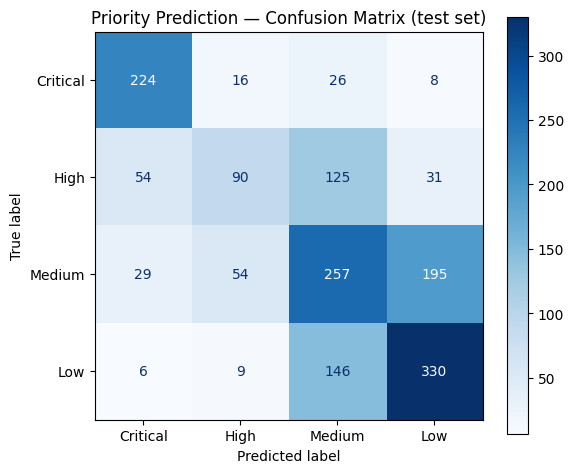

In [10]:
labels_order = ["Critical", "High", "Medium", "Low"]
labels_order = [l for l in labels_order if l in np.unique(y_test)]

cm = confusion_matrix(y_test, y_pred, labels=labels_order)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_order)
disp.plot(ax=ax, cmap="Blues", colorbar=True, values_format="d")
ax.set_title("Priority Prediction — Confusion Matrix (test set)")
plt.tight_layout()
plt.show()

## 6. Feature importance

Random Forest's built-in (Gini) importances across all TF-IDF + numeric + category features.
Per the Week 1 EDA finding, `days_to_deadline` is expected to come out on top.

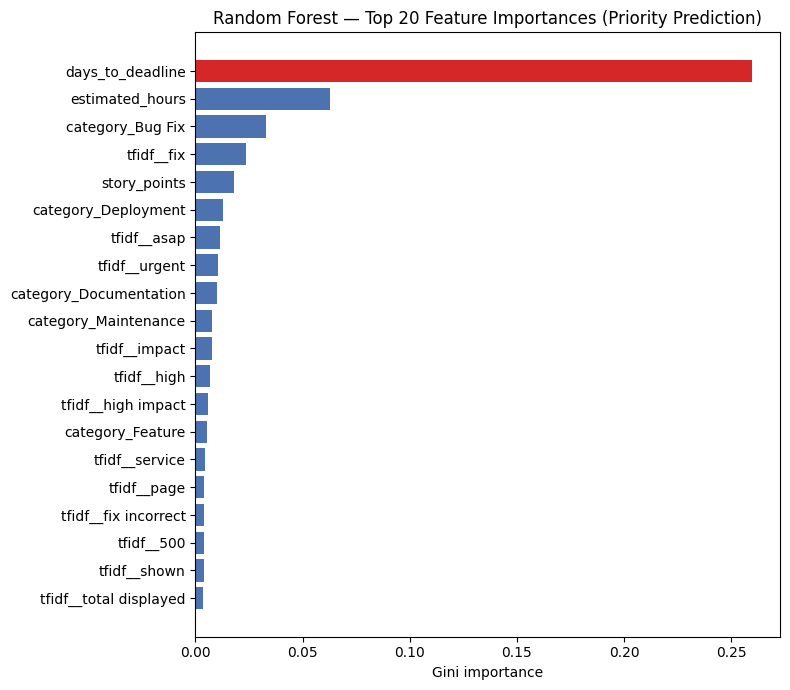

#1 feature by importance: days_to_deadline (0.2598)
Matches the Week 1 EDA finding: days_to_deadline is the strongest single predictor.

Top 10 features:
days_to_deadline          0.2598
estimated_hours           0.0630
category_Bug Fix          0.0330
tfidf__fix                0.0236
story_points              0.0182
category_Deployment       0.0130
tfidf__asap               0.0116
tfidf__urgent             0.0103
category_Documentation    0.0103
category_Maintenance      0.0077
dtype: float64


In [11]:
importances = best_rf.feature_importances_
imp_series = pd.Series(importances, index=feature_names).sort_values(ascending=False)

top_n = 20
top_imp = imp_series.head(top_n).iloc[::-1]

colors = ["#d62728" if f == "days_to_deadline" else "#4C72B0" for f in top_imp.index]

fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(top_imp.index, top_imp.values, color=colors)
ax.set_xlabel("Gini importance")
ax.set_title(f"Random Forest — Top {top_n} Feature Importances (Priority Prediction)")
plt.tight_layout()
plt.show()

top_feature = imp_series.index[0]
print(f"#1 feature by importance: {top_feature} ({imp_series.iloc[0]:.4f})")
if top_feature == "days_to_deadline":
    print("Matches the Week 1 EDA finding: days_to_deadline is the strongest single predictor.")
else:
    print("NOTE: top feature differs from the Week 1 EDA expectation - worth a closer look.")

print("\nTop 10 features:")
print(imp_series.head(10).round(4))

## 7. Persist the tuned model

Save the fitted pipeline pieces (Random Forest, category encoder, feature name list, and the
grid-search results) so the model can be reloaded or compared later without retraining.

In [12]:
os.makedirs(MODELS_DIR, exist_ok=True)

joblib.dump(best_rf, f"{MODELS_DIR}/priority_rf_model.joblib")
joblib.dump(cat_encoder, f"{MODELS_DIR}/priority_category_encoder.joblib")
joblib.dump(list(feature_names), f"{MODELS_DIR}/priority_rf_feature_names.joblib")

manifest = {
    "target": TARGET_COL,
    "features": {
        "tfidf": {"source": f"{MODELS_DIR}/tfidf_train.joblib / tfidf_test.joblib",
                   "n_features": int(len(tfidf_feature_names))},
        "numeric": NUMERIC_COLS,
        "category_encoded": list(cat_feature_names),
    },
    "split": {
        "source": f"{MODELS_DIR}/train_idx.joblib / test_idx.joblib",
        "n_train": int(len(train_idx)),
        "n_test": int(len(test_idx)),
    },
    "model": "RandomForestClassifier",
    "grid_search": {
        "param_grid": param_grid,
        "scoring": "f1_macro",
        "cv_folds": 5,
        "best_params": grid_search.best_params_,
        "best_cv_macro_f1": float(grid_search.best_score_),
    },
    "test_metrics": {
        "accuracy": float(acc),
        "macro_precision": float(macro_precision),
        "macro_recall": float(macro_recall),
        "macro_f1": float(macro_f1),
    },
    "top_feature": str(imp_series.index[0]),
}

with open(f"{MODELS_DIR}/priority_rf_manifest.json", "w") as f:
    json.dump(manifest, f, indent=2, default=str)

print(json.dumps(manifest, indent=2, default=str))

{
  "target": "priority",
  "features": {
    "tfidf": {
      "source": "data/processed/features/tfidf_train.joblib / tfidf_test.joblib",
      "n_features": 1495
    },
    "numeric": [
      "days_to_deadline",
      "estimated_hours",
      "story_points"
    ],
    "category_encoded": [
      "category_Bug Fix",
      "category_Deployment",
      "category_Documentation",
      "category_Feature",
      "category_Maintenance",
      "category_Research",
      "category_Testing"
    ]
  },
  "split": {
    "source": "data/processed/features/train_idx.joblib / test_idx.joblib",
    "n_train": 6400,
    "n_test": 1600
  },
  "model": "RandomForestClassifier",
  "grid_search": {
    "param_grid": {
      "n_estimators": [
        100,
        300
      ],
      "max_depth": [
        null,
        20
      ],
      "min_samples_leaf": [
        1,
        4
      ],
      "class_weight": [
        null,
        "balanced"
      ]
    },
    "scoring": "f1_macro",
    "cv_folds": 5,
  

### Summary

- Random Forest tuned via `GridSearchCV` over `n_estimators`, `max_depth`, `min_samples_leaf`,
  and `class_weight`, scored on macro-F1 (5-fold stratified CV) so the rare `Critical` class
  isn't ignored.
- Evaluated on the exact same held-out rows (`test_idx` from `models/`) that every other model in
  the project uses, so results are directly comparable across notebooks.
- `days_to_deadline` is the top feature by Gini importance, matching the Week 1 EDA finding that
  deadline proximity is the strongest single signal for task priority.

**message suggestion:**
`feat(model): train + tune Random Forest for priority prediction on shared TF-IDF + numeric features`
